# Emotion Detection from Text using DistilRoBERTa

## Overview

This project builds a Natural Language Processing (NLP) model that detects emotions from English text using a pretrained transformer model from Hugging Face.

The model classifies each sentence into one of six emotions:

- 😢 Sadness
- 😊 Joy
- ❤️ Love
- 😠 Anger
- 😨 Fear
- 😲 Surprise

Unlike traditional machine learning approaches such as Naive Bayes or Support Vector Machines, transformer models understand words in context, enabling them to capture subtle emotional meaning in text.

---

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing
5. Tokenization
6. Build the Model
7. Train the Model
8. Evaluate Performance
9. Make Predictions
10. Save the Model

In [1]:
# ==========================================================
# 1. Import Libraries
# ==========================================================

import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
# ==========================================================
# 2. Reproducibility
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("✅ Random seed set to", SEED)

✅ Random seed set to 42


In [3]:
# ==========================================================
# 3. Load Dataset
# ==========================================================

DATASET_PATH = "/kaggle/input/datasets/parulpandey/emotion-dataset"

train_df = pd.read_csv(f"{DATASET_PATH}/training.csv")
val_df = pd.read_csv(f"{DATASET_PATH}/validation.csv")
test_df = pd.read_csv(f"{DATASET_PATH}/test.csv")

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (16000, 2)
Validation: (2000, 2)
Testing: (2000, 2)


In [4]:
# ==========================================================
# 4. Basic Inspection
# ==========================================================

train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


In [6]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

# 5. Exploratory Data Analysis (EDA)

Before training the model, we explore the dataset to better understand:

- Class distribution
- Sentence lengths
- Dataset balance

This helps us choose appropriate training parameters and identify potential issues such as class imbalance.

In [7]:
train_df["label"].value_counts().sort_index()

label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64

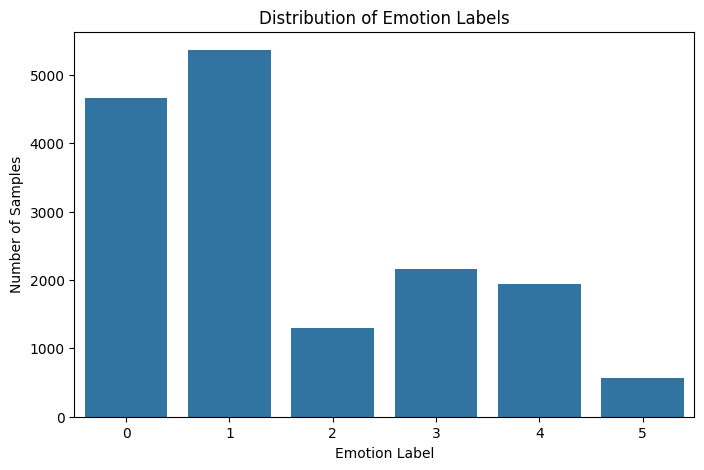

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="label"
)

plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion Label")
plt.ylabel("Number of Samples")

plt.show()

In [9]:
train_df["text_length"] = train_df["text"].str.split().str.len()

In [10]:
train_df["text_length"].describe()

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: text_length, dtype: float64

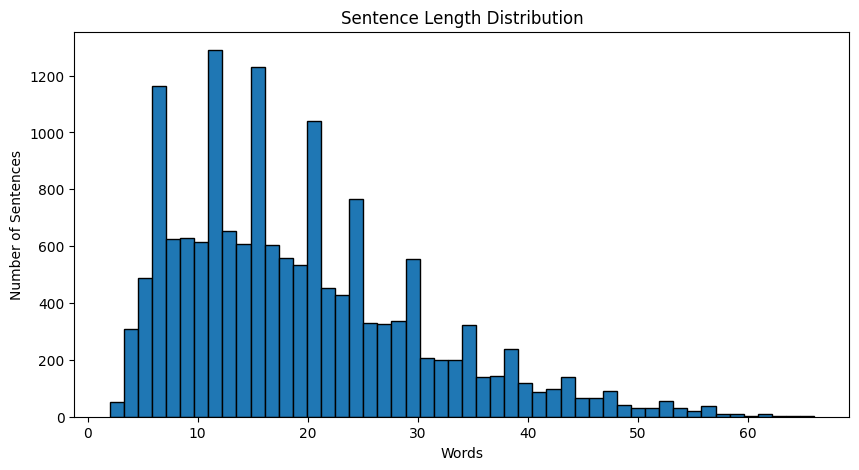

In [11]:
plt.figure(figsize=(10,5))

plt.hist(
    train_df["text_length"],
    bins=50,
    edgecolor="black"
)

plt.title("Sentence Length Distribution")
plt.xlabel("Words")
plt.ylabel("Number of Sentences")

plt.show()

In [12]:
print("Longest sentence:", train_df["text_length"].max())

Longest sentence: 66


# 6. Text Preprocessing

Unlike traditional NLP pipelines, transformer models such as DistilRoBERTa are trained on natural text.

Therefore, we perform only minimal preprocessing to preserve punctuation, contractions and other contextual information that may contribute to emotion recognition.

In [13]:
def clean_text(text):
    """
    Perform minimal preprocessing while preserving
    important linguistic information.
    """
    text = str(text)

    # Remove extra whitespace
    text = " ".join(text.split())

    return text

In [14]:
train_df["text"] = train_df["text"].apply(clean_text)
val_df["text"] = val_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

In [15]:
train_df.head()

,text,label,text_length
0,i didnt feel humiliated,0,4
1,i can go from feeling so hopeless to so damned...,0,21
2,im grabbing a minute to post i feel greedy wrong,3,10
3,i am ever feeling nostalgic about the fireplac...,2,18
4,i am feeling grouchy,3,4


# 7. Preparing the Dataset

The Hugging Face Trainer does not work directly with pandas DataFrames.

Therefore, the pandas DataFrames are converted into Hugging Face `Dataset` objects.

This allows efficient tokenization, batching and training.

In [16]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print("Training dataset:", train_dataset)
print("Validation dataset:", val_dataset)
print("Testing dataset:", test_dataset)

Training dataset: Dataset({
    features: ['text', 'label', 'text_length'],
    num_rows: 16000
})
Validation dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Testing dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})


# 8. Tokenization

Transformer models cannot process raw text.

The tokenizer converts each sentence into numerical token IDs that the model can understand.

It also creates an attention mask, which tells the model which tokens belong to the actual sentence and which are padding.

In [17]:
MODEL_NAME = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully!


In [18]:
sample_text = train_df.loc[0, "text"]

print(sample_text)

i didnt feel humiliated


In [19]:
encoded = tokenizer(sample_text)

encoded

{'input_ids': [0, 118, 46405, 619, 32386, 2], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [20]:
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

print(tokens)

['<s>', 'i', 'Ġdidnt', 'Ġfeel', 'Ġhumiliated', '</s>']


# 9. Tokenization

Transformer models cannot understand raw text.

The tokenizer converts each sentence into numerical token IDs and creates an attention mask.

The Hugging Face `map()` function is then used to efficiently tokenize every sentence in the dataset.

In [21]:
# ==========================================================
# Tokenization Function
# ==========================================================

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,
        max_length=64
    )

In [22]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [23]:
tokenized_train

Dataset({
    features: ['text', 'label', 'text_length', 'input_ids', 'attention_mask'],
    num_rows: 16000
})

In [24]:
tokenized_train[0]

{'text': 'i didnt feel humiliated',
 'label': 0,
 'text_length': 4,
 'input_ids': [0, 118, 46405, 619, 32386, 2],
 'attention_mask': [1, 1, 1, 1, 1, 1]}

# 10. Load the Pre-trained Model

A pretrained DistilRoBERTa model is loaded and adapted for emotion classification.

The final classification layer is configured to predict six emotion classes.

In [25]:
# ==========================================================
# Load Pretrained Model
# ==========================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label={
        0: "sadness",
        1: "joy",
        2: "love",
        3: "anger",
        4: "fear",
        5: "surprise",
    },
    label2id={
        "sadness": 0,
        "joy": 1,
        "love": 2,
        "anger": 3,
        "fear": 4,
        "surprise": 5,
    },
)

print("✅ Model loaded successfully!")

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded successfully!


# 11. Dynamic Padding

The data collator dynamically pads each batch during training.

Instead of padding every sentence in the dataset to the same length, only the sentences within the current batch are padded to match the longest sentence in that batch. This reduces memory usage and speeds up training.

In [26]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("✅ Data collator created successfully!")


✅ Data collator created successfully!


# 12. Evaluation Metrics

During training, the model's performance is measured using multiple evaluation metrics.

Instead of relying only on accuracy, we also calculate precision, recall and F1-score because the emotion classes are imbalanced.

In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    """
    Compute evaluation metrics for the model.
    """

    logits, labels = eval_pred

    # Convert logits into predicted class indices
    predictions = np.argmax(logits, axis=-1)

    # Calculate accuracy
    accuracy = accuracy_score(labels, predictions)

    # Calculate precision, recall and F1-score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

print("✅ Evaluation metrics ready!")

✅ Evaluation metrics ready!


# 13. Training Configuration

TrainingArguments defines how the model should train.

These settings control:

- Number of epochs
- Learning rate
- Batch size
- Evaluation strategy
- Model checkpoint saving

In [28]:
# ==========================================================
# Training Configuration
# ==========================================================

training_args = TrainingArguments(

    output_dir="./emotion_model",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    seed=42
)

print("✅ Training arguments configured.")

✅ Training arguments configured.


# 14. Create the Trainer

The Hugging Face Trainer combines the model, datasets, tokenizer, data collator, evaluation metrics and training configuration into one object that manages the complete training process.

In [29]:
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_val,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics

)

print("✅ Trainer created successfully!")

✅ Trainer created successfully!


In [30]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.582721,0.436964,0.920000,0.924844,0.920000,0.921103
2,0.373984,0.303008,0.941500,0.941724,0.941500,0.940974
3,0.265665,0.284931,0.938000,0.938928,0.938000,0.938198


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1500, training_loss=0.618951062520345, metrics={'train_runtime': 224.7155, 'train_samples_per_second': 213.603, 'train_steps_per_second': 6.675, 'total_flos': 640202648381568.0, 'train_loss': 0.618951062520345, 'epoch': 3.0})

In [31]:
trainer.evaluate()

{'eval_loss': 0.3026360869407654,
 'eval_accuracy': 0.9415,
 'eval_precision': 0.9417238281267021,
 'eval_recall': 0.9415,
 'eval_f1': 0.9409743545324422,
 'eval_runtime': 3.2333,
 'eval_samples_per_second': 618.567,
 'eval_steps_per_second': 19.485,
 'epoch': 3.0}

In [32]:
print(model.config.id2label)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [33]:
import torch
import torch.nn.functional as F

text = "I am afraid to talk to him."

# Tokenize
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

# Move inputs to the same device as the model
device = next(model.parameters()).device
inputs = {k: v.to(device) for k, v in inputs.items()}

# Evaluation mode
model.eval()

# Predict
with torch.no_grad():
    outputs = model(**inputs)

# Convert logits to probabilities
probabilities = F.softmax(outputs.logits, dim=1)

predicted_class = torch.argmax(probabilities, dim=1).item()
confidence = probabilities[0][predicted_class].item()

print("Text:", text)
print("Predicted emotion:", model.config.id2label[predicted_class])
print(f"Confidence: {confidence:.2%}")

Text: I am afraid to talk to him.
Predicted emotion: fear
Confidence: 96.03%


In [34]:
trainer.save_model("/kaggle/working/emotion_model")
tokenizer.save_pretrained("/kaggle/working/emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/emotion_model/tokenizer_config.json',
 '/kaggle/working/emotion_model/tokenizer.json')

In [35]:
import os
print(os.listdir("/kaggle/working"))

['emotion_model', '__notebook__.ipynb']


In [36]:
print(os.listdir("/kaggle/working/emotion_model"))

['tokenizer.json', 'config.json', 'checkpoint-500', 'training_args.bin', 'model.safetensors', 'checkpoint-1000', 'tokenizer_config.json', 'checkpoint-1500']


# Final Test Evaluation

Evaluate the trained model on the unseen test dataset.
This gives the final performance of the model.

In [37]:
test_results = trainer.evaluate(tokenized_test)

print(test_results)

{'eval_loss': 0.3370203971862793, 'eval_accuracy': 0.922, 'eval_precision': 0.9222393231611433, 'eval_recall': 0.922, 'eval_f1': 0.9216202819009729, 'eval_runtime': 3.2585, 'eval_samples_per_second': 613.788, 'eval_steps_per_second': 19.334, 'epoch': 3.0}


# Confusion Matrix Libraries

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Function to generate predictions

In [39]:
def get_predictions(dataset):

    predictions = trainer.predict(dataset)

    preds = np.argmax(predictions.predictions, axis=1)

    labels = predictions.label_ids

    return preds, labels

# Training Confusion Matrix

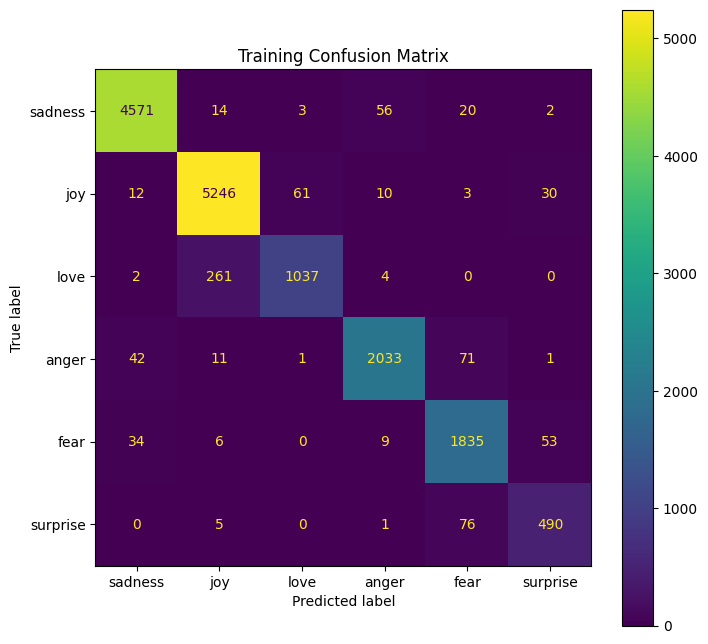

              precision    recall  f1-score   support

     sadness       0.98      0.98      0.98      4666
         joy       0.95      0.98      0.96      5362
        love       0.94      0.80      0.86      1304
       anger       0.96      0.94      0.95      2159
        fear       0.92      0.95      0.93      1937
    surprise       0.85      0.86      0.85       572

    accuracy                           0.95     16000
   macro avg       0.93      0.92      0.92     16000
weighted avg       0.95      0.95      0.95     16000



In [40]:
train_preds, train_labels = get_predictions(tokenized_train)

cm = confusion_matrix(train_labels, train_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(model.config.id2label.values())
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax)

plt.title("Training Confusion Matrix")
plt.show()

print(classification_report(
    train_labels,
    train_preds,
    target_names=list(model.config.id2label.values())
))

# Validation Confusion Matrix

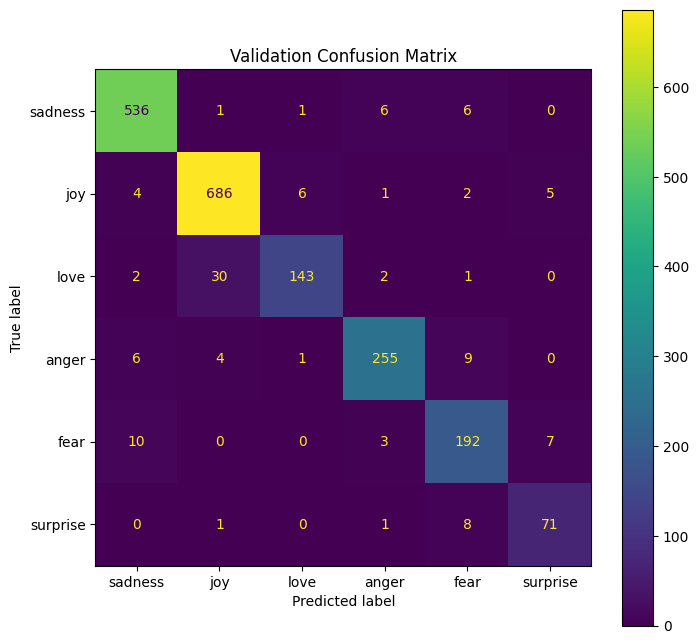

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97       550
         joy       0.95      0.97      0.96       704
        love       0.95      0.80      0.87       178
       anger       0.95      0.93      0.94       275
        fear       0.88      0.91      0.89       212
    surprise       0.86      0.88      0.87        81

    accuracy                           0.94      2000
   macro avg       0.92      0.91      0.92      2000
weighted avg       0.94      0.94      0.94      2000



In [41]:
val_preds, val_labels = get_predictions(tokenized_val)

cm = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(model.config.id2label.values())
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax)

plt.title("Validation Confusion Matrix")
plt.show()

print(classification_report(
    val_labels,
    val_preds,
    target_names=list(model.config.id2label.values())
))

# Test Confusion Matrix

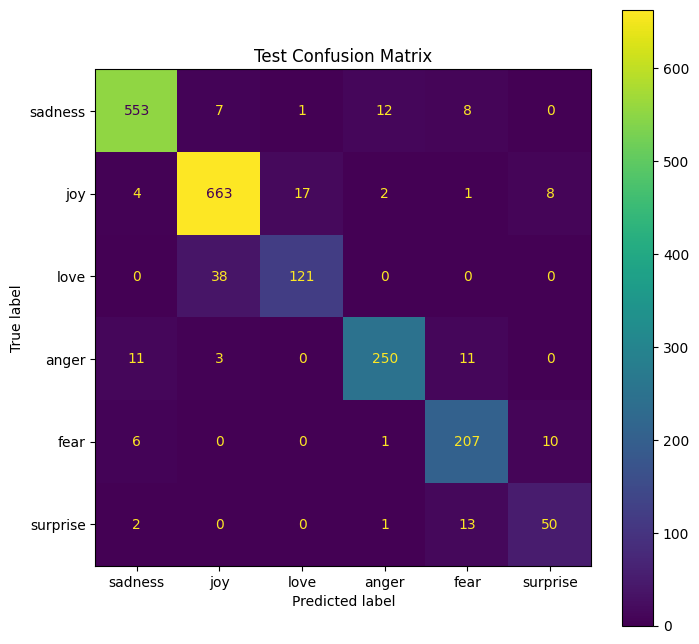

              precision    recall  f1-score   support

     sadness       0.96      0.95      0.96       581
         joy       0.93      0.95      0.94       695
        love       0.87      0.76      0.81       159
       anger       0.94      0.91      0.92       275
        fear       0.86      0.92      0.89       224
    surprise       0.74      0.76      0.75        66

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



In [42]:
test_preds, test_labels = get_predictions(tokenized_test)

cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(model.config.id2label.values())
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax)

plt.title("Test Confusion Matrix")
plt.show()

print(classification_report(
    test_labels,
    test_preds,
    target_names=list(model.config.id2label.values())
))

In [43]:
import shutil

shutil.make_archive(
    "/kaggle/working/emotion_model",
    "zip",
    "/kaggle/working/emotion_model"
)

print("emotion_model.zip created successfully!")

emotion_model.zip created successfully!
